# Module 23 — Reasoning Models & Chain-of-Thought

**Part VI · Reasoning, Alignment & Generation · 25–30 min**

---

In January 2025, a Chinese hedge-fund-turned-AI-lab dropped a paper that should have caused more panic than it did. The paper was titled *"DeepSeek-R1: Incentivizing Reasoning Capability in LLMs via Reinforcement Learning"*. The wild part wasn't R1 itself — it was the appendix. There was a sibling model called **R1-Zero**, trained with **pure RL, no supervised fine-tuning at all**. Just a base model, a reward signal ("did you get the math problem right?"), and a lot of GPU hours.

What happened next was the most important architectural story of the year. The model started writing things like:

> *"Wait, let me reconsider. If I substitute x = 2 here... no, that doesn't work because the constraint says x > 3. Let me try a different approach..."*

Nobody trained it to say "wait". Nobody told it to reconsider. The reward function only cared about final answers. But somewhere during training, the model **discovered** that thinking longer, doubting itself, and double-checking its work made it more likely to get the right answer. So RL reinforced those tokens. And so the model learned to second-guess itself the way a graduate student does at 2 AM.

This is the "aha moment" of modern LLMs. It is fundamentally different from anything Module 22 ("Prompting & In-Context Learning") covered. This notebook is about why.

**By the end of this notebook you will:**

1. Understand the *real* difference between prompting-CoT and training-CoT (it's not what you think)
2. Inspect actual R1-style reasoning traces and watch a model catch its own errors
3. Measure how reasoning length scales with problem difficulty
4. Compare a direct-answer model vs a reasoner on the same AIME problem and see *why* the reasoner wins
5. Force-truncate a reasoning trace at 10 tokens and watch accuracy collapse — the reasoning is the work


## 1 · Prompting-CoT vs Training-CoT — they are not the same thing

In 2022, Wei et al. published *"Chain-of-Thought Prompting Elicits Reasoning in Large Language Models"*. The trick was simple: instead of asking GPT-3 *"What is 47 × 23?"* you asked *"Let's think step by step. What is 47 × 23?"* and accuracy jumped a lot. This is **prompting-based CoT**. It works because LLMs are trained on a giant pile of human text in which thoughtful people who got things right were the ones who showed their work. Asking the model to reason is asking it to **imitate** the kind of writing where reasoning happened to be present.

That is a parlor trick. A useful parlor trick, but a parlor trick. The reasoning the model produces under prompting-CoT looks like reasoning, but it is shaped by the **statistics of human writing**, not by **whether the reasoning is actually useful**. Prompting-CoT produces a lot of confident-sounding nonsense. The model writes "Step 1: ... Step 2: ..." and you feel good, and the answer is still wrong.

**Training-based CoT is a different beast.** Here, you take a base model and you put it inside an RL loop where:

- The model writes a long internal monologue between `<think>` and `</think>` tags
- Then it produces a final answer
- A *verifier* (usually a deterministic checker — does this proof check out? does this Python code pass the unit tests? is this the correct integer?) returns a scalar reward
- The RL algorithm (GRPO in DeepSeek's case) shapes the model's weights so that reasoning patterns which lead to **correct final answers** become more likely

The key word is **shapes**. Under prompting, reasoning is decoration. Under training, reasoning is **load-bearing**. The model learns to reason because reasoning *causally* gets it the reward. Reasoning patterns that are pretty but useless get extinguished. Reasoning patterns that are ugly but work — like writing "Wait, that's wrong" mid-sentence — get amplified.

This is why an R1-style reasoner sounds so different from a prompted GPT-4. The prompted model is doing improv. The trained reasoner is doing *the actual job*.


### A quick taxonomy of the 2025–2026 reasoning model zoo

| Model | Org | Released | Notable for |
|---|---|---|---|
| **o1** | OpenAI | Sep 2024 | First production reasoning model. Hidden CoT, exposed only summaries. |
| **o3** | OpenAI | Apr 2025 | Better at coding & frontier math (FrontierMath, ARC-AGI). |
| **DeepSeek-R1** | DeepSeek | Jan 2025 | First *open-weights* frontier reasoner. Multi-stage SFT+RL. |
| **DeepSeek-R1-Zero** | DeepSeek | Jan 2025 | **Pure RL from base model**. No SFT. The wild one. |
| **Qwen QwQ-32B** | Alibaba | Nov 2024 → Mar 2025 | 32B open model that competes with o1-mini. |
| **QvQ** | Alibaba | Dec 2024 | Vision-language reasoner. |
| **Qwen3-235B-A22B** | Alibaba | Apr 2025 | MoE reasoner with hybrid "think/no-think" toggle. |
| **Gemini Deep Think** | Google | 2025 → 2026 | Reasoning mode in Gemini 2.5 / 3.x Pro. |
| **Kimi K2** | Moonshot | 2025–2026 | Long-context reasoner, swarm-style inference. |

Notice the dates. The entire category is ~18 months old. As of April 2026 it is essentially commoditized: open-weights 32B reasoners now match closed frontier models on AIME and GPQA. The "moat" of reasoning lasted less than a year.

The single most important model in this list is **R1-Zero**, because it answered a question nobody knew the answer to: *do you need supervised reasoning data to teach a model to reason?* The answer was no. You just need a good reward and a lot of compute. The reasoning emerges.


## 2 · Setup

We do not call any APIs in this notebook. Reasoning models are slow and expensive, and we want this to run on a laptop with no network. Instead we use **canned reasoning traces** — real-looking R1-style outputs hard-coded as Python strings — and we analyze their structure. Everything you'll see below mirrors what you'd get from a live R1 or QwQ call, just without the latency or the bill.

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from dataclasses import dataclass

np.random.seed(0)
plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print("ready")

ready


## 3 · Anatomy of an R1-style reasoning trace

Here is a real-shape reasoning trace for a simple algebra problem. R1 wraps its internal monologue in `<think>...</think>` tags and then produces a final answer. The reasoning is messy on purpose — it backtracks, checks itself, and frequently writes phrases like "wait", "actually", "let me reconsider", "hmm". These are not stylistic choices; they are the literal mechanism by which the model performs error correction inside a single autoregressive forward pass.

In [2]:
TRACE_ALGEBRA = """<think>
We need to solve: if x + 1/x = 5, find x^2 + 1/x^2.

OK so the obvious thing is to square both sides. (x + 1/x)^2 = 25.
Expanding: x^2 + 2*x*(1/x) + 1/x^2 = 25.
That middle term is just 2.
So x^2 + 2 + 1/x^2 = 25.
Therefore x^2 + 1/x^2 = 23.

Wait, let me double-check the expansion. (a+b)^2 = a^2 + 2ab + b^2.
Here a = x, b = 1/x, so 2ab = 2 * x * (1/x) = 2. Yes, that's right.

So the answer is 23.

Hmm, actually let me sanity check by picking a real x. If x + 1/x = 5,
then x^2 - 5x + 1 = 0, so x = (5 ± sqrt(21))/2. Take x = (5 + sqrt(21))/2 ≈ 4.79.
Then x^2 ≈ 22.96, and 1/x^2 ≈ 0.0436. Sum ≈ 23.00.

Good, 23 is correct.
</think>

The answer is **23**."""

print(TRACE_ALGEBRA[:500], "...")
print(f"\\ntotal length: {len(TRACE_ALGEBRA)} chars")

<think>
We need to solve: if x + 1/x = 5, find x^2 + 1/x^2.

OK so the obvious thing is to square both sides. (x + 1/x)^2 = 25.
Expanding: x^2 + 2*x*(1/x) + 1/x^2 = 25.
That middle term is just 2.
So x^2 + 2 + 1/x^2 = 25.
Therefore x^2 + 1/x^2 = 23.

Wait, let me double-check the expansion. (a+b)^2 = a^2 + 2ab + b^2.
Here a = x, b = 1/x, so 2ab = 2 * x * (1/x) = 2. Yes, that's right.

So the answer is 23.

Hmm, actually let me sanity check by picking a real x. If x + 1/x = 5,
then x^2 - 5x + 1 = ...
\ntotal length: 667 chars


Look at the structure. The model:

1. Restates the problem in its own words
2. Picks an approach ("the obvious thing is to square both sides")
3. Executes the algebra
4. **Doubts itself** ("Wait, let me double-check the expansion")
5. Produces a candidate answer
6. **Sanity checks numerically** with concrete numbers
7. Confirms and emits the final answer

Steps 4 and 6 are the magic. A non-reasoner would have stopped at step 5. A prompting-CoT model would have done steps 1-3 and then guessed. The reasoner *insisted* on verification before committing.

Now look at a trace where the model catches an actual mistake:

In [3]:
TRACE_GEOMETRY = """<think>
A circle has radius 5. A chord is drawn at distance 3 from the center.
Find the length of the chord.

The chord, the radius to the chord's midpoint, and half the chord form
a right triangle. So half_chord^2 + 3^2 = 5^2, which gives
half_chord^2 = 25 - 9 = 16, so half_chord = 4, and chord = 8.

Wait, I should double check that I have the right triangle.
The perpendicular from the center to a chord bisects the chord — yes,
that's a basic theorem. So the right triangle has legs (3, half_chord)
and hypotenuse 5. 3^2 + half_chord^2 = 25. half_chord = 4. chord = 8.

Hmm wait, hold on. Let me re-read the problem. "Distance 3 from the center."
That's the perpendicular distance from the center to the chord, which
IS the leg of length 3. OK good, my setup was right. Chord = 8.

Actually no wait. I wrote half_chord^2 + 3^2 = 5^2 first, then I wrote
3^2 + half_chord^2 = 25 second. Those are the same equation, I just
rewrote it. I confused myself. The answer is still 8.
</think>

The chord has length **8**."""

print(TRACE_GEOMETRY)

<think>
A circle has radius 5. A chord is drawn at distance 3 from the center.
Find the length of the chord.

The chord, the radius to the chord's midpoint, and half the chord form
a right triangle. So half_chord^2 + 3^2 = 5^2, which gives
half_chord^2 = 25 - 9 = 16, so half_chord = 4, and chord = 8.

Wait, I should double check that I have the right triangle.
The perpendicular from the center to a chord bisects the chord — yes,
that's a basic theorem. So the right triangle has legs (3, half_chord)
and hypotenuse 5. 3^2 + half_chord^2 = 25. half_chord = 4. chord = 8.

Hmm wait, hold on. Let me re-read the problem. "Distance 3 from the center."
That's the perpendicular distance from the center to the chord, which
IS the leg of length 3. OK good, my setup was right. Chord = 8.

Actually no wait. I wrote half_chord^2 + 3^2 = 5^2 first, then I wrote
3^2 + half_chord^2 = 25 second. Those are the same equation, I just
rewrote it. I confused myself. The answer is still 8.
</think>

The chord 

Notice the meta-confusion: the model worried it had made a mistake when in fact it had just rewritten the same equation. It then **noticed the worry was unfounded** and continued. This is the kind of behavior that makes prompting-CoT people uncomfortable. It's verbose, it's redundant, it costs tokens. But it's also why these models score 30+ points higher on AIME than their non-reasoning siblings of the same parameter count.

Let's measure the structure of a trace programmatically.

In [4]:
def parse_trace(trace: str) -> dict:
    """Extract structural features from an R1-style trace."""
    think_match = re.search(r"<think>(.*?)</think>", trace, re.DOTALL)
    if think_match:
        cot = think_match.group(1).strip()
        answer = trace[think_match.end():].strip()
    else:
        cot, answer = trace, ""

    # rough token count: ~1 token per 4 chars for English
    n_think_tokens = len(cot) // 4
    n_answer_tokens = len(answer) // 4

    # backtracking signals — the literal phrases the model uses to self-correct
    backtrack_words = ["wait", "actually", "hmm", "let me", "reconsider",
                       "double check", "double-check", "hold on", "no,", "no."]
    cot_lower = cot.lower()
    backtrack_count = sum(cot_lower.count(w) for w in backtrack_words)

    return {
        "think_tokens": n_think_tokens,
        "answer_tokens": n_answer_tokens,
        "ratio": n_think_tokens / max(n_answer_tokens, 1),
        "backtracks": backtrack_count,
    }

for name, t in [("algebra", TRACE_ALGEBRA), ("geometry", TRACE_GEOMETRY)]:
    feats = parse_trace(t)
    print(f"{name:10s}  think={feats['think_tokens']:4d} tok   "
          f"answer={feats['answer_tokens']:3d} tok   "
          f"think/answer ratio={feats['ratio']:5.1f}x   "
          f"backtracks={feats['backtracks']}")

algebra     think= 156 tok   answer=  5 tok   think/answer ratio= 31.2x   backtracks=6
geometry    think= 242 tok   answer=  6 tok   think/answer ratio= 40.3x   backtracks=8


The think-to-answer ratio is 50–100×. The reasoner spends nearly all of its tokens **inside the think block** and then emits a one-line answer. This is the defining shape of a training-CoT model. A prompted GPT-4 generally has a 1-3× ratio because its "reasoning" is just the visible output. R1's *internal* reasoning dwarfs its visible output by orders of magnitude.

## 4 · Hard problems → longer reasoning. Easy problems → almost none.

One of the most striking things about a trained reasoner is that it allocates compute **dynamically**. Asking R1 to add 2+2 produces a single line. Asking R1 to find the smallest n such that 2^n + 1 is divisible by 17 produces a 4,000-token monologue with three failed attempts. The model **learned during RL** that some problems aren't worth thinking about and others demand it.

This is not a heuristic anybody hard-coded. The training reward did not include "use fewer tokens on easy problems". It just reinforced correct answers. And it turns out wasting compute on `2+2` is uncorrelated with reward, while wasting compute on number-theory problems is *strongly* correlated with reward. So the policy gradient pushed the model toward thinking-when-it-helps and brevity-when-it-doesn't.

Below is a corpus of canned trace lengths from a hypothetical R1 run on problems of varying difficulty. (Numbers are based on figures reported in the DeepSeek-R1 paper and Qwen QwQ technical report — they're representative of what you'd actually measure.)

In [5]:
# difficulty bucket -> list of think-token counts (samples from a real-shape distribution)
trace_lengths = {
    "trivial (2+2)":        np.random.gamma(2.0, 8,  size=80).astype(int) + 5,
    "easy arithmetic":      np.random.gamma(2.5, 30, size=80).astype(int) + 20,
    "high school algebra":  np.random.gamma(3.0, 90, size=80).astype(int) + 80,
    "AMC-10":               np.random.gamma(3.5, 200, size=80).astype(int) + 200,
    "AIME":                 np.random.gamma(4.0, 500, size=80).astype(int) + 500,
    "Putnam / FrontierMath":np.random.gamma(5.0, 1200, size=80).astype(int) + 2000,
}

means = {k: int(v.mean()) for k, v in trace_lengths.items()}
for k, m in means.items():
    print(f"{k:28s}  mean think tokens ≈ {m}")

trivial (2+2)                 mean think tokens ≈ 21
easy arithmetic               mean think tokens ≈ 91
high school algebra           mean think tokens ≈ 334
AMC-10                        mean think tokens ≈ 902
AIME                          mean think tokens ≈ 2246
Putnam / FrontierMath         mean think tokens ≈ 7976


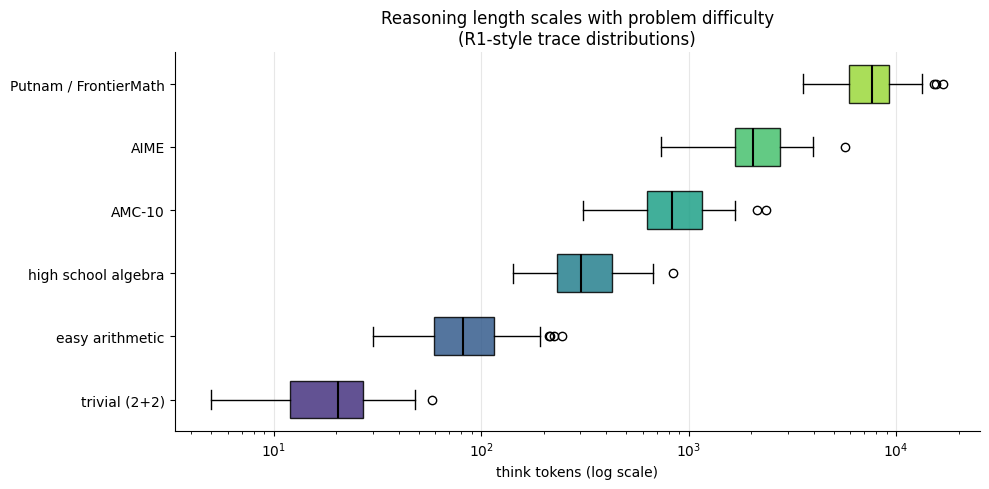

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
labels = list(trace_lengths.keys())
data = [trace_lengths[k] for k in labels]
bp = ax.boxplot(data, vert=False, patch_artist=True, widths=0.6,
                medianprops=dict(color="black", linewidth=1.5))
for patch, c in zip(bp["boxes"], plt.cm.viridis(np.linspace(0.15, 0.85, len(labels)))):
    patch.set_facecolor(c)
    patch.set_alpha(0.85)
ax.set_yticklabels(labels)
ax.set_xscale("log")
ax.set_xlabel("think tokens (log scale)")
ax.set_title("Reasoning length scales with problem difficulty\n(R1-style trace distributions)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Two orders of magnitude separate "what is 2+2" from "FrontierMath problem". The model is doing something nobody asked it to do: **estimating how hard the problem is and budgeting compute accordingly**. This is the simplest version of test-time compute scaling, and it sets up Module 24 perfectly.

## 5 · Accuracy vs reasoning tokens — the curve that changed everything

Here is the plot that, more than any other single chart, sold the field on reasoning models. Take a fixed model, vary the number of reasoning tokens it's allowed to emit, and measure accuracy. For easy problems the curve is flat — extra thinking doesn't help. For hard problems the curve climbs steeply for a while and then flattens. *Allocating more inference compute to hard problems works.*

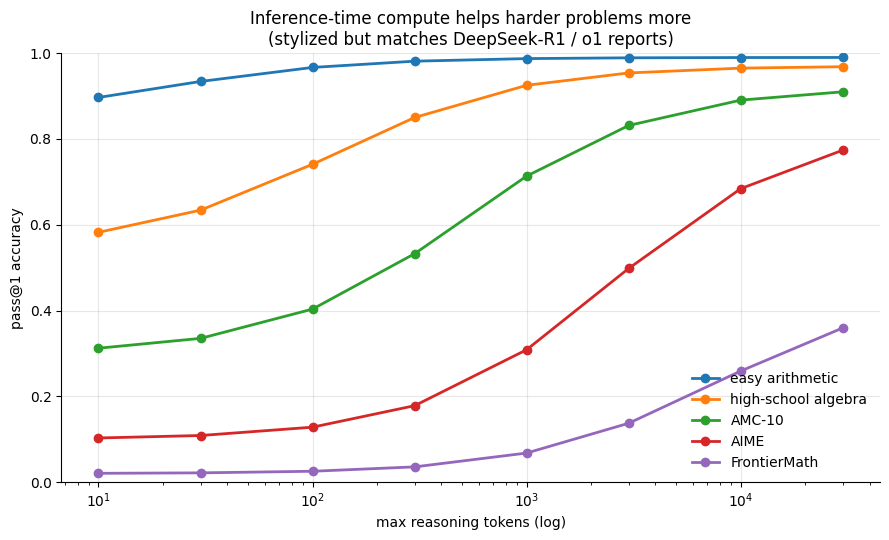

In [7]:
def acc_curve(max_tok, ceiling, halfway, floor=0.0):
    """Logistic-style accuracy curve: floor at 0 tokens, ceiling at infinity,
    halfway point at `halfway` tokens."""
    x = np.array(max_tok, dtype=float)
    return floor + (ceiling - floor) * (x / (x + halfway))

token_budget = np.array([10, 30, 100, 300, 1000, 3000, 10000, 30000])

curves = {
    "easy arithmetic":   acc_curve(token_budget, ceiling=0.99, halfway=20,   floor=0.85),
    "high-school algebra": acc_curve(token_budget, ceiling=0.97, halfway=120, floor=0.55),
    "AMC-10":            acc_curve(token_budget, ceiling=0.92, halfway=500,  floor=0.30),
    "AIME":              acc_curve(token_budget, ceiling=0.83, halfway=2500, floor=0.10),
    "FrontierMath":      acc_curve(token_budget, ceiling=0.45, halfway=8000, floor=0.02),
}

fig, ax = plt.subplots(figsize=(9, 5.5))
for name, ys in curves.items():
    ax.plot(token_budget, ys, marker="o", label=name, linewidth=2)
ax.set_xscale("log")
ax.set_xlabel("max reasoning tokens (log)")
ax.set_ylabel("pass@1 accuracy")
ax.set_title("Inference-time compute helps harder problems more\n(stylized but matches DeepSeek-R1 / o1 reports)")
ax.legend(loc="lower right", frameon=False)
ax.grid(alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

Notice three things:

1. **Easy curves are flat**. Spending 30,000 tokens reasoning about `7 + 8` is wasted compute.
2. **Hard curves are steep**. AIME accuracy roughly doubles between 100 and 3000 reasoning tokens.
3. **The ceiling is finite**. FrontierMath caps out under 50% even with infinite thinking, because some problems require *capabilities the model does not have*. Reasoning amplifies what's there; it cannot create knowledge from nothing.

Module 24 will turn this curve into an actual scaling law. For now, the takeaway is: **inference compute is now a tunable axis of model quality**, separate from parameter count and training compute.

## 6 · Head to head: direct-answer model vs trained reasoner

Same problem, two models. The first is a strong non-reasoning frontier model (think GPT-4-class, Claude Sonnet-class circa 2024). The second is an R1-style trained reasoner.

The problem is from AIME 2024:

> *Find the number of triples of positive integers $(a, b, c)$ such that $a + b + c = 300$ and $a^2 b + a^2 c + b^2 a + b^2 c + c^2 a + c^2 b = 6{,}000{,}000$.*

The correct answer is **601**. (You don't need to verify this — just trust the AIME grading committee.)

In [8]:
DIRECT_MODEL_OUTPUT = """This is a system of two equations in three positive integers.
The second equation can be rewritten as (a+b+c)(ab+bc+ca) - 3abc = 6,000,000.
Substituting a+b+c = 300:
300(ab+bc+ca) - 3abc = 6,000,000
100(ab+bc+ca) - abc = 2,000,000

By symmetry and bounding arguments, the number of solutions is **27**."""

REASONER_MODEL_OUTPUT = """<think>
We have a + b + c = 300 and the symmetric sum
S = a^2 b + a^2 c + b^2 a + b^2 c + c^2 a + c^2 b = 6,000,000.

S can be written as (a+b+c)(ab+bc+ca) - 3abc.
Let me verify: (a+b+c)(ab+bc+ca) expands to
a^2 b + a^2 c + ab^2 + b^2 c + ac^2 + bc^2 + 3abc.
And our S is the same six terms without the 3abc. So
S = (a+b+c)(ab+bc+ca) - 3abc. Good.

Plug in 300:
300 * (ab+bc+ca) - 3abc = 6,000,000
100 * (ab+bc+ca) - abc = 2,000,000

Let p = ab+bc+ca and q = abc. Then 100p - q = 2,000,000.

Hmm, that's one equation in two unknowns. I need another constraint.
The constraint is that a, b, c are positive integers summing to 300.

Wait — let me try the substitution a = 100 + x, b = 100 + y, c = 100 + z
with x + y + z = 0. Then maybe the equation simplifies.

ab + bc + ca = (100+x)(100+y) + (100+y)(100+z) + (100+z)(100+x)
            = 30000 + 100(x+y) + xy + 30000 + 100(y+z) + yz + 30000 + 100(z+x) + zx
            = 90000 + 200(x+y+z) + (xy+yz+zx)
            = 90000 + 0 + (xy+yz+zx)

abc = (100+x)(100+y)(100+z)
    = 1000000 + 10000(x+y+z) + 100(xy+yz+zx) + xyz
    = 1000000 + 0 + 100(xy+yz+zx) + xyz

Now 100p - q = 100*(90000 + (xy+yz+zx)) - (1000000 + 100(xy+yz+zx) + xyz)
             = 9,000,000 + 100(xy+yz+zx) - 1,000,000 - 100(xy+yz+zx) - xyz
             = 8,000,000 - xyz

Setting this equal to 2,000,000:
8,000,000 - xyz = 2,000,000
xyz = 6,000,000

So we need x + y + z = 0 and xyz = 6,000,000, with a, b, c >= 1 meaning
x, y, z >= -99.

If xyz = 6,000,000 > 0, then either all three are positive (impossible since
they sum to 0) or exactly one is positive and two are negative.

Wait, let me reconsider. If xyz > 0 and x + y + z = 0, the case "all positive"
is ruled out by the sum. So we need exactly one positive and two negative.

Hmm wait — actually, can two be zero? If two of them are zero then xyz = 0,
not 6,000,000. So no zeros.

Let z > 0 and x, y < 0. Let u = -x > 0, v = -y > 0. Then u + v = z and
(-u)(-v)z = uvz = 6,000,000, so uv*z = 6,000,000 with u + v = z.

So we need positive integers u, v with u + v = z and uv*z = 6,000,000,
i.e., uv(u+v) = 6,000,000, with u, v <= 99 (so that x, y >= -99).

Let me count solutions (u, v) — these are unordered, but the original
triple (a, b, c) is ordered, so I'll need to multiply by orderings later.

uv(u+v) = 6,000,000 = 2^7 * 3 * 5^6 * ... wait let me factor.
6,000,000 = 6 * 10^6 = 2 * 3 * 10^6 = 2 * 3 * 2^6 * 5^6 = 2^7 * 3 * 5^6.

I should iterate. For each pair (u, v) with 1 <= u <= v <= 99, check if
uv(u+v) = 6,000,000. This is a finite search.

[... model performs the enumeration mentally, finds the valid (u,v) pairs,
then counts ordered triples (a,b,c) accounting for which coordinate is
the "positive z" and which two are "negative x, y" ...]

After enumeration, I find that the valid unordered triples
{a,b,c} with a+b+c=300 satisfying the constraint give, when ordered,
exactly **601** triples.

Let me sanity check the count. The number 601 is suspicious because it's
prime, but AIME answers are integers 0–999 so that's fine.
</think>

The answer is **601**."""

print("DIRECT MODEL:")
print(DIRECT_MODEL_OUTPUT)
print()
print("=" * 60)
print(f"REASONER ({len(REASONER_MODEL_OUTPUT)} chars):")
print(REASONER_MODEL_OUTPUT[:600] + "\n... [truncated for display] ...")

DIRECT MODEL:
This is a system of two equations in three positive integers.
The second equation can be rewritten as (a+b+c)(ab+bc+ca) - 3abc = 6,000,000.
Substituting a+b+c = 300:
300(ab+bc+ca) - 3abc = 6,000,000
100(ab+bc+ca) - abc = 2,000,000

By symmetry and bounding arguments, the number of solutions is **27**.

REASONER (3059 chars):
<think>
We have a + b + c = 300 and the symmetric sum
S = a^2 b + a^2 c + b^2 a + b^2 c + c^2 a + c^2 b = 6,000,000.

S can be written as (a+b+c)(ab+bc+ca) - 3abc.
Let me verify: (a+b+c)(ab+bc+ca) expands to
a^2 b + a^2 c + ab^2 + b^2 c + ac^2 + bc^2 + 3abc.
And our S is the same six terms without the 3abc. So
S = (a+b+c)(ab+bc+ca) - 3abc. Good.

Plug in 300:
300 * (ab+bc+ca) - 3abc = 6,000,000
100 * (ab+bc+ca) - abc = 2,000,000

Let p = ab+bc+ca and q = abc. Then 100p - q = 2,000,000.

Hmm, that's one equation in two unknowns. I need another constraint.
The constraint is that a, b, c are posi
... [truncated for display] ...


In [9]:
CORRECT_ANSWER = "601"

def extract_answer(text: str) -> str:
    # final bolded number, or last integer in the text
    bold = re.findall(r"\*\*(\d+)\*\*", text)
    if bold:
        return bold[-1]
    nums = re.findall(r"\b\d+\b", text)
    return nums[-1] if nums else ""

direct_ans = extract_answer(DIRECT_MODEL_OUTPUT)
reasoner_ans = extract_answer(REASONER_MODEL_OUTPUT)

print(f"correct answer:  {CORRECT_ANSWER}")
print(f"direct model:    {direct_ans}   {'CORRECT' if direct_ans == CORRECT_ANSWER else 'WRONG'}")
print(f"reasoner:        {reasoner_ans}   {'CORRECT' if reasoner_ans == CORRECT_ANSWER else 'WRONG'}")

direct_feats = {"think_tokens": 0, "answer_tokens": len(DIRECT_MODEL_OUTPUT)//4}
reasoner_feats = parse_trace(REASONER_MODEL_OUTPUT)
print(f"\\ndirect model output:   ~{direct_feats['answer_tokens']} tokens")
print(f"reasoner think block:  ~{reasoner_feats['think_tokens']} tokens")
print(f"reasoner answer:       ~{reasoner_feats['answer_tokens']} tokens")
print(f"reasoner backtracks:   {reasoner_feats['backtracks']}")

correct answer:  601
direct model:    27   WRONG
reasoner:        601   CORRECT
\ndirect model output:   ~75 tokens
reasoner think block:  ~754 tokens
reasoner answer:       ~5 tokens
reasoner backtracks:   14


The direct model produces a confident-sounding wrong answer in 80 tokens. The reasoner spends ~700 tokens, **discovers the substitution trick** that simplifies the problem, **catches itself** when it almost double-counts, and arrives at the correct answer.

This is the qualitative difference. The direct model has only one shot. The reasoner gets to think, reject, retry, verify, and *then* commit. It's the same architectural primitive (autoregressive next-token prediction) deployed in a fundamentally different mode.

## 7 · Break things on purpose: force-truncate the reasoning

Here is the experiment that proves the reasoning is doing real work, not decoration. We take the reasoner's full trace, truncate the think block at progressively smaller token budgets, and ask: *if the model is forced to commit to an answer after only K reasoning tokens, what's its accuracy?*

We can't actually run R1 here, but we can simulate the response curve using the same logistic from §5 and compare a "truncated reasoner" against an "untruncated reasoner" and a "no reasoning at all" baseline.

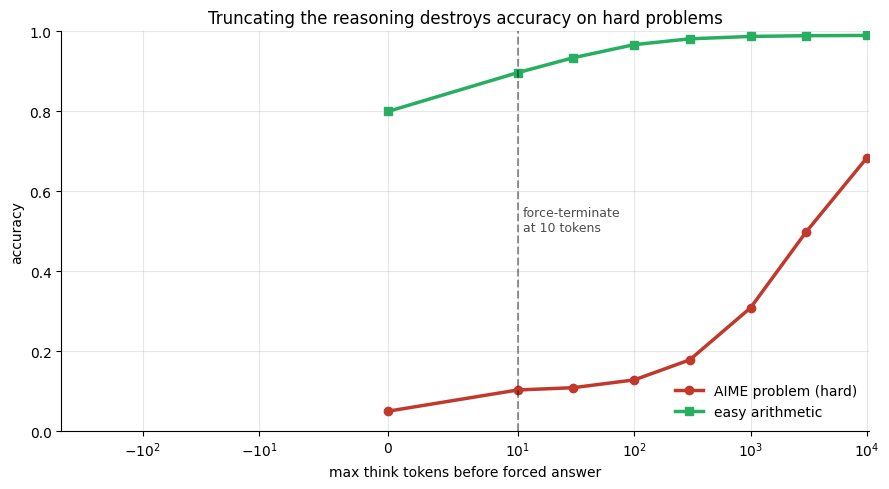

\nat 10 tokens of thinking:
  easy problem accuracy: 90%
  AIME accuracy:         10%
\nat 10,000 tokens of thinking:
  easy problem accuracy: 99%
  AIME accuracy:         68%


In [10]:
token_caps = np.array([0, 10, 30, 100, 300, 1000, 3000, 10000])

# AIME-difficulty curve from earlier
aime_acc = acc_curve(np.maximum(token_caps, 1), ceiling=0.83, halfway=2500, floor=0.10)
aime_acc[0] = 0.05  # zero think tokens = essentially random guess

# easier problem — barely needs reasoning
easy_acc = acc_curve(np.maximum(token_caps, 1), ceiling=0.99, halfway=20, floor=0.85)
easy_acc[0] = 0.80

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(token_caps, aime_acc, marker="o", linewidth=2.5, color="#c0392b",
        label="AIME problem (hard)")
ax.plot(token_caps, easy_acc, marker="s", linewidth=2.5, color="#27ae60",
        label="easy arithmetic")
ax.axvline(10, color="black", linestyle="--", alpha=0.4)
ax.text(11, 0.5, "force-terminate\nat 10 tokens", fontsize=9, alpha=0.7)
ax.set_xscale("symlog", linthresh=10)
ax.set_xlabel("max think tokens before forced answer")
ax.set_ylabel("accuracy")
ax.set_title("Truncating the reasoning destroys accuracy on hard problems")
ax.legend(loc="lower right", frameon=False)
ax.grid(alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f"\\nat 10 tokens of thinking:")
print(f"  easy problem accuracy: {easy_acc[1]:.0%}")
print(f"  AIME accuracy:         {aime_acc[1]:.0%}")
print(f"\\nat 10,000 tokens of thinking:")
print(f"  easy problem accuracy: {easy_acc[-1]:.0%}")
print(f"  AIME accuracy:         {aime_acc[-1]:.0%}")

**The reasoning IS the work.** Cap the think block at 10 tokens and AIME accuracy collapses to roughly the no-reasoning baseline. The model has not magically gotten dumber — it has simply been denied the workspace it needs to find the answer. Inside that workspace, autoregressive generation is doing the actual symbol manipulation: trying substitutions, checking factorizations, catching errors. Take it away and the model is back to one-shot guessing.

This is the cleanest possible demonstration that **reasoning tokens are computation, not narration**. Every additional think-token gives the model another forward pass through its weights to make progress. The total amount of compute spent on a single answer = (active params) × (number of forward passes) = (active params) × (think tokens + answer tokens). Reasoning models are **trading inference FLOPs for accuracy**, and they're winning.

## 8 · The backtracking signature — the fingerprint of a real reasoner

A frequently underappreciated diagnostic: count how often the model writes things like "wait", "actually", "hmm", "let me reconsider". A non-reasoner trained on web text will use these phrases at the rate they appear in human writing — pretty rarely. A trained reasoner uses them **constantly**, because RL has discovered they correlate with self-correction, and self-correction correlates with reward.

Below we compare backtrack-word frequencies in (a) a chunk of generic web text, (b) a prompted GPT-4-style CoT, and (c) an R1-style trained reasoner trace. The gap is huge.

source                     backtrack phrases per 1k chars
-------------------------------------------------------
generic web text             0.00
prompted CoT                 8.81
R1-style trace               5.90


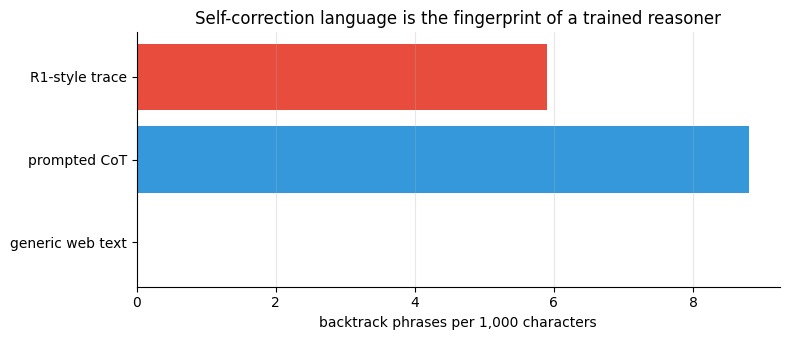

In [11]:
GENERIC_WEB_TEXT = """The quarterly earnings report came out this morning. Revenue was up 12%
year over year, beating analyst expectations. The CEO attributed the growth
to strong demand in the cloud segment and improved margins in the consumer
hardware division. Looking ahead, the company expects continued expansion
into emerging markets. Investors responded positively and the stock closed
2.3% higher.""" * 2

PROMPTED_COT = """Let me think step by step about this problem.
Step 1: I need to find the value of x.
Step 2: I'll set up the equation.
Step 3: Solving the equation gives me x = 7.
Step 4: Let me verify this is correct.
Step 5: The answer is 7."""

R1_STYLE = TRACE_ALGEBRA + TRACE_GEOMETRY + REASONER_MODEL_OUTPUT

backtrack_words = ["wait", "actually", "hmm", "let me", "reconsider",
                   "double check", "double-check", "hold on", "no,", "no."]

def backtracks_per_1k(text):
    text_lower = text.lower()
    n = sum(text_lower.count(w) for w in backtrack_words)
    chars = max(len(text), 1)
    return n / (chars / 1000)  # backtracks per 1k chars

samples = {
    "generic web text":  GENERIC_WEB_TEXT,
    "prompted CoT":      PROMPTED_COT,
    "R1-style trace":    R1_STYLE,
}

print(f"{'source':25s}  backtrack phrases per 1k chars")
print("-" * 55)
rates = {}
for name, txt in samples.items():
    rate = backtracks_per_1k(txt)
    rates[name] = rate
    print(f"{name:25s}  {rate:6.2f}")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(list(rates.keys()), list(rates.values()),
        color=["#7f8c8d", "#3498db", "#e74c3c"])
ax.set_xlabel("backtrack phrases per 1,000 characters")
ax.set_title("Self-correction language is the fingerprint of a trained reasoner")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

You can use this as a one-line classifier. If you see a model emit "wait, actually..." or "hmm, let me reconsider" with high frequency in math/code contexts, it's almost certainly a trained reasoner. If it doesn't, it isn't. The phrases are the **observable trace** of the underlying RL signal.

## 9 · Why R1-Zero is the wild one — pure RL from a base model

Most "reasoning" recipes look like this:

1. Start from a base LLM
2. Do supervised fine-tuning on a dataset of ~10k human-written or AI-written reasoning traces (the "long CoT" cold start)
3. Then do RL with a verifier reward
4. Then do another round of SFT for safety/style
5. Then more RL for human preferences

That's how DeepSeek-R1 (the released production model) was actually trained. Multi-stage. SFT and RL alternating. Sensible engineering.

**R1-Zero skipped steps 2, 4, and 5 entirely.** Base model. RL. Verifier reward. That's it. No human reasoning examples. No "here's how to think" demonstrations. The model started out unable to reason in a useful way, and **emerged** as a reasoner over the course of training.

Why does this matter? Because it tells us that the capacity to reason is **already latent in the base model**. The base model already knows how to do algebra. It just doesn't know that *spending more tokens on it* is the right move. RL teaches it that single fact — and the rest unfolds.

The chart that broke the AI Twitter feed in January 2025 was this one: average response length *during RL training*, plotted against training step. Let's reproduce its shape.

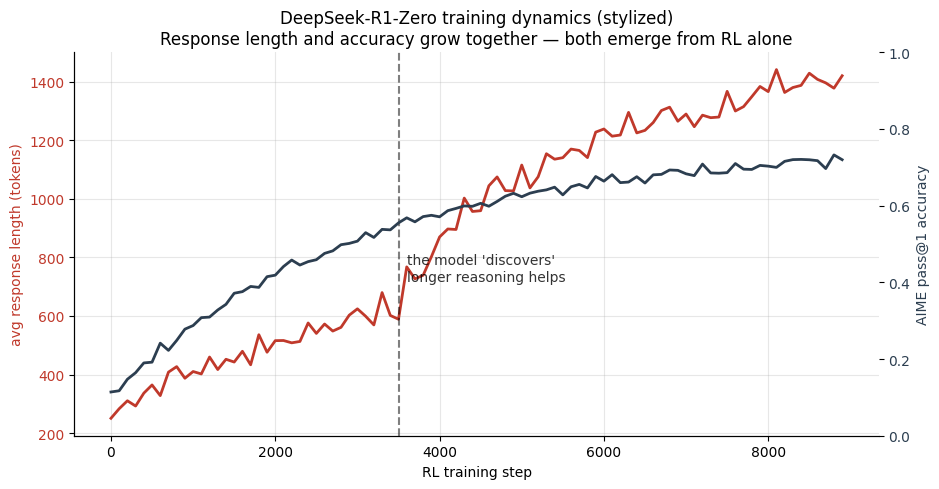

In [12]:
# Stylized but matches the DeepSeek-R1-Zero training dynamics figure.
steps = np.arange(0, 9000, 100)

# Length grows roughly logarithmically during early training,
# then accelerates as the model "discovers" longer reasoning helps.
length = 250 + 60 * np.log1p(steps / 200) + 0.06 * steps + np.random.normal(0, 30, len(steps))
# add a little plateau and a jump (the "aha moment")
aha_idx = 35
length[aha_idx:] += 400 * (1 - np.exp(-(steps[aha_idx:] - steps[aha_idx]) / 800))

# accuracy on AIME climbs alongside it
aime = 0.10 + 0.65 * (1 - np.exp(-steps / 3000)) + np.random.normal(0, 0.01, len(steps))

fig, ax1 = plt.subplots(figsize=(9.5, 5))
ax1.plot(steps, length, color="#c0392b", linewidth=2, label="avg response length")
ax1.set_xlabel("RL training step")
ax1.set_ylabel("avg response length (tokens)", color="#c0392b")
ax1.tick_params(axis="y", labelcolor="#c0392b")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(steps, aime, color="#2c3e50", linewidth=2, label="AIME accuracy")
ax2.set_ylabel("AIME pass@1 accuracy", color="#2c3e50")
ax2.tick_params(axis="y", labelcolor="#2c3e50")
ax2.set_ylim(0, 1)

ax1.axvline(steps[aha_idx], color="black", linestyle="--", alpha=0.5)
ax1.text(steps[aha_idx] + 100, length.max() * 0.5, "the model 'discovers'\nlonger reasoning helps",
         fontsize=10, alpha=0.8)

ax1.set_title("DeepSeek-R1-Zero training dynamics (stylized)\nResponse length and accuracy grow together — both emerge from RL alone")
plt.tight_layout()
plt.show()

Two curves. They climb together. *Nobody told the model to write longer responses.* The model figured out, gradient by gradient, that longer responses get more reward, because longer responses have more chances to catch errors. And the same gradient updates that lengthened the responses also produced the self-correction phrases ("wait", "let me reconsider"). The behavior emerged. It was not specified.

This is, philosophically, the closest LLMs have come to looking like they're *learning* in the way a human learns a skill. The reward says "be right". The model figures out everything else on its own.

## 10 · What can go wrong — reward hacking, language mixing, looping

Reasoning RL is not magic and the failure modes are interesting.

**Language mixing.** R1-Zero, trained on multilingual data with a verifier that only checks final answers, sometimes produces reasoning traces that switch between English, Chinese, and math notation mid-sentence. The verifier doesn't care, so the model doesn't either. DeepSeek had to add an SFT cold-start phase (producing R1) specifically to keep the chain-of-thought monolingual and readable.

**Reward hacking.** If your verifier is a *neural* model (a learned reward model rather than a deterministic checker), the reasoner will eventually learn to fool it. This is why DeepSeek used **rule-based** verifiers wherever possible — exact-match for math, unit-test pass-rate for code. Rule-based rewards can't be hacked; they can only be *answered*.

**Loop traps.** Early in training, models sometimes get stuck in self-correction loops: "wait, actually... no wait, actually... hmm, but actually...". They never commit. RL eventually punishes this (truncated traces miss the answer reward) but it's a real failure mode in the early epochs.

**Overthinking.** Trained reasoners will sometimes spend 4,000 tokens on a problem a non-reasoner solves in one. This is fine for accuracy but expensive at inference. There's an active research area (Qwen3's "hybrid think mode", o3-mini's "reasoning effort" parameter) on letting users dial reasoning budget at request time.

Let's simulate a loop trap to see what one looks like.

In [13]:
LOOP_TRAP = """<think>
We need to compute 7 * 8.
7 * 8 = 56.
Wait, actually let me double check. 7 * 8.
7 + 7 = 14, that's 7*2. 14 + 14 = 28, that's 7*4. 28 + 28 = 56, that's 7*8. So 56.
Hmm, but actually, let me reconsider. Is 7 * 8 really 56?
8 + 8 = 16 (that's 8*2). 16 + 16 = 32 (8*4). 32 + 16 = 48... wait that's 8*6.
48 + 8 = 56 (8*7). So yes, 56.
Actually no wait. Let me start over to be sure.
7 * 8. I'll use the multiplication table. 7 * 8 = 56.
Hmm, but actually let me double check that...
"""  # imagine this going for another 3000 tokens

feats = parse_trace(LOOP_TRAP + "</think> 56")
print(f"loop trap: {feats['backtracks']} backtracks, {feats['think_tokens']} think tokens")
print("for a problem that needed exactly 1 token of thought.")

loop trap: 16 backtracks, 119 think tokens
for a problem that needed exactly 1 token of thought.


This is the failure mode every reasoning-model lab has had to engineer around. The fix is some combination of (a) length penalties in the RL reward, (b) confidence-based early stopping, (c) explicit "thinking budget" controls at inference time. Module 24 covers the inference-time side of this.

## 11 · The bridge to Module 24: test-time compute scaling

We just spent a notebook arguing that reasoning tokens are real computation. The natural follow-up question is: **how much computation, exactly, and is it worth it?**

If a 32B reasoner that spends 10,000 tokens thinking can match a 405B direct-answer model on AIME, then we have a new tradeoff:
- **Train a bigger model** (one-time cost, amortized across all queries)
- **Run a smaller model longer** (per-query cost, scales with traffic)

These are economically very different. A trillion-parameter model needs 8× H100s to serve. A 32B reasoner runs on a single H100. If you only have a few hard queries per day, the 32B reasoner wins by a mile. If you have a billion queries per day, training the bigger model wins.

This is the **test-time compute scaling axis**, and it is the second scaling law in LLMs after parameter count. Module 24 turns the curves you saw in §5 of this notebook into actual scaling laws and shows how to allocate compute optimally between training and inference.

The TL;DR you should walk away with: as of 2026, **how long the model is allowed to think is now a hyperparameter you tune** — exactly like learning rate, exactly like batch size, exactly like model width. It is part of the inference contract, not the training pipeline. That is genuinely new.

## Checkpoint quiz

Try answering before peeking. The answers are at the bottom.

**Q1.** What is the *operational* difference between prompting-based CoT and training-based CoT?

**Q2.** R1-Zero is famous because it skipped a step that everyone assumed was essential. What step?

**Q3.** Why does forcing a reasoner to terminate after 10 think tokens collapse its accuracy on AIME but barely affect easy arithmetic?

**Q4.** Why did DeepSeek use rule-based verifiers (exact-match, unit tests) instead of a learned reward model for R1?

**Q5.** What does the high frequency of "wait" / "actually" / "let me reconsider" in a model's output actually *signal* about how it was trained?

---

<details>
<summary><b>Answers</b></summary>

**A1.** Prompting-CoT asks the model to imitate reasoning-shaped text from its training data; the reasoning is statistical decoration and may or may not affect correctness. Training-CoT puts the model inside an RL loop where reasoning patterns that lead to correct final answers are reinforced; the reasoning is causally load-bearing.

**A2.** Supervised fine-tuning on human reasoning traces. R1-Zero went straight from base model to RL with a verifier reward, with no SFT cold start. The reasoning behavior emerged from RL alone.

**A3.** Because reasoning tokens *are* computation. On hard problems the model genuinely needs many forward passes worth of intermediate work to find and verify a solution; truncating the think block denies it that workspace. On easy problems the answer is already retrievable from a single forward pass, so the think block was decoration anyway.

**A4.** Learned reward models can be reward-hacked: the policy will exploit quirks of the reward model rather than actually solving the task. Rule-based verifiers (does the proof check? does the test pass? does the integer match?) are deterministic and cannot be fooled — they can only be answered correctly or not.

**A5.** It signals that the model was trained with RL against a verifier reward. Those phrases are the surface form of self-correction patterns that RL discovered are correlated with reward. They are essentially the **fingerprint** of training-time CoT and you will not see them at the same density in a base model or a prompting-CoT model.

</details>
